# Modelagem Preditiva do Valor de Mercado na Bundesliga

Projeto: Mineracao Estatistica e Modelagem Preditiva de Valor de Ativos no Mercado de Futebol (SME0829).

Este notebook executa a fase preditiva prevista nos Proximos Passos do relatorio parcial. Partindo do dataset integrado `dataset_bundesliga_5seasons.csv` (Transfermarkt cruzado com SofaScore, temporadas de 22/23 a 25/26), treinamos modelos de regressao para estimar o valor de mercado (`market_value`) de um jogador a partir das suas estatisticas de desempenho, da idade e da posicao.

O objetivo final nao e apenas a previsao em si. Como o relatorio destaca, o que interessa ao clube e usar o erro do modelo para encontrar jogadores mal precificados: quando o modelo preve um valor maior que o de mercado, o desempenho sugere um ativo subvalorizado; quando preve menos, ha risco de sobrepreco.

Roteiro:

1. Carga e limpeza dos dados
2. Engenharia de variaveis (metricas por 90 minutos, eficiencia, idade)
3. Estrategia de validacao por jogador, para nao vazar informacao entre treino e teste
4. Treino e comparacao de modelos
5. Avaliacao das metricas, incluindo o erro por faixa de valor
6. Explicabilidade: entender o que o modelo aprendeu
7. Aplicacao pratica: ranking de jogadores subvalorizados e supervalorizados

In [1]:
# Bibliotecas de manipulacao de dados e graficos.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ferramentas de modelagem do scikit-learn.
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score
from sklearn.compose import ColumnTransformer          # aplica transformacoes diferentes por coluna
from sklearn.pipeline import Pipeline                  # encadeia pre-processamento + modelo
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.dummy import DummyRegressor               # modelo trivial usado como referencia
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             mean_absolute_percentage_error)
from xgboost import XGBRegressor

# Estilo visual e semente fixa para tornar os resultados reprodutiveis.
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
RANDOM_STATE = 42

## 1. Carga e limpeza

O alvo da regressao e o `market_value`, em euros. Removemos tres tipos de registro que atrapalhariam o aprendizado:

1. Sem valor de mercado, cerca de 5 por cento, que sao jogadores nao mapeados no Transfermarkt.
2. Com valor igual a zero, que representam informacao ausente ou ruido.
3. Com menos de 450 minutos jogados na temporada. Abaixo desse limite a amostra em campo e pequena demais, as metricas por 90 minutos ficam instaveis e o valor de mercado reflete pouca coisa observavel. Esse foi o mesmo criterio de participacao minima adotado na analise exploratoria do relatorio.

In [2]:
df = pd.read_csv("dataset_bundesliga_5seasons.csv")
print("Dataset bruto:", df.shape)

# Filtros de qualidade descritos acima, aplicados em sequencia.
df = df.dropna(subset=["market_value"])     # remove alvo ausente
df = df[df["market_value"] > 0]             # remove valor zero (indefinido)
df = df[df["minutesPlayed"] >= 450].copy()  # exige participacao minima relevante

print("Apos limpeza:", df.shape)
print("Temporadas:", sorted(df["season"].unique()))
print("Jogadores unicos:", df["player_name"].nunique())
df.head(3)

Dataset bruto: (1980, 28)
Apos limpeza: (1351, 28)
Temporadas: ['Bundesliga 22/23', 'Bundesliga 23/24', 'Bundesliga 24/25', 'Bundesliga 25/26']
Jogadores unicos: 690


,season,team,player_name,player_sofa_id,tm_href,position,position_label,birth_date,age,market_value,...,yellowCards,redCards,shotsOnTarget,accuratePassesPercentage,keyPasses,successfulDribblesPercentage,tackles,interceptions,bigChancesCreated,bigChancesMissed
2,Bundesliga 25/26,1. FC Union Berlin,Christopher Trimmel,48557,/christopher-trimmel/profil/spieler/75921,M,Meio-campo,1987-02-24,38.4,600000.0,...,8,0,1,68.04,53,16.67,38,11,11,0
5,Bundesliga 25/26,1. FC Union Berlin,Leopold Querfeld,1086547,/leopold-querfeld/profil/spieler/597432,D,Defensor,2003-12-20,21.6,20000000.0,...,6,0,10,79.95,21,57.14,52,36,3,2
6,Bundesliga 25/26,1. FC Union Berlin,Diogo Leite,855663,/diogo-leite/profil/spieler/357156,D,Defensor,1999-01-23,26.5,12000000.0,...,4,0,1,76.49,9,50.00,33,43,0,2


## 2. Engenharia de variaveis

As estatisticas brutas favorecem quem joga mais minutos. Para comparar titulares e reservas de forma justa, criamos indicadores derivados que normalizam o desempenho pelo tempo em campo e capturam eficiencia.

Metricas por 90 minutos, com sufixo `_p90`: gols, assistencias, chutes ao gol, passes-chave, desarmes, interceptacoes e grandes chances criadas. Sao a taxa de producao a cada jogo completo.

Alem delas:

`goals_assists` e `ga_p90` medem o volume ofensivo total, absoluto e por 90 minutos.

`conv_rate` e a taxa de conversao, gols dividido por chutes ao gol, ou seja, o quao clinico e o jogador na finalizacao.

`fin_vs_xg` compara os gols marcados com os gols esperados (`expectedGoals`). Valor positivo indica quem finaliza acima do esperado, valor negativo indica desperdicio.

`create_vs_xa` faz o mesmo para assistencias contra assistencias esperadas.

`start_ratio` e a proporcao de jogos em que o atleta foi titular.

`age_sq` e a idade ao quadrado. O valor de mercado costuma ter um pico por volta dos 24 aos 27 anos e cair nos extremos, entao a relacao com a idade nao e linear. O termo quadrático permite ao modelo linear capturar essa curva.

A idade e a posicao vem do SofaScore, coletadas do endpoint `/player/{id}`, e sao variaveis de forte impacto na precificacao. Onde `expectedGoals` esta ausente (goleiros ou jogadores sem finalizacoes) preenchemos com zero.

In [3]:
# expectedGoals/Assists ausentes ocorrem em goleiros e quem nao finaliza: valem zero.
df["expectedGoals"] = df["expectedGoals"].fillna(0.0)
df["expectedAssists"] = df["expectedAssists"].fillna(0.0)

# Converte contagens absolutas em taxa por 90 minutos: (evento / minutos) * 90.
per90 = ["goals", "assists", "shotsOnTarget", "keyPasses",
         "tackles", "interceptions", "bigChancesCreated"]
for c in per90:
    df[c + "_p90"] = df[c] / df["minutesPlayed"] * 90

# Volume ofensivo total e por 90.
df["goals_assists"] = df["goals"] + df["assists"]
df["ga_p90"] = df["goals_assists"] / df["minutesPlayed"] * 90

# Eficiencia de finalizacao. np.where evita divisao por zero quando nao houve chute ao gol.
df["conv_rate"] = np.where(df["shotsOnTarget"] > 0, df["goals"] / df["shotsOnTarget"], 0.0)

# Desempenho observado menos o esperado: mede se o jogador supera as expectativas.
df["fin_vs_xg"] = df["goals"] - df["expectedGoals"]
df["create_vs_xa"] = df["assists"] - df["expectedAssists"]

# Titularidade. clip(lower=1) protege contra divisao por zero em appearances.
df["start_ratio"] = df["matchesStarted"] / df["appearances"].clip(lower=1)

# Termo quadratico da idade para modelar o pico de carreira.
df["age_sq"] = df["age"] ** 2

print("Variaveis derivadas criadas.")
df[[c + "_p90" for c in per90] + ["ga_p90", "conv_rate", "fin_vs_xg", "age"]].describe().round(2)

Variaveis derivadas criadas.


,goals_p90,assists_p90,shotsOnTarget_p90,keyPasses_p90,tackles_p90,interceptions_p90,bigChancesCreated_p90,ga_p90,conv_rate,fin_vs_xg,age
count,1351.00,1351.00,1351.00,1351.00,1351.00,1351.00,1351.00,1351.00,1351.00,1351.00,1351.00
mean,0.14,0.10,0.44,0.91,1.46,0.78,0.17,0.25,0.27,0.09,26.24
std,0.18,0.12,0.44,0.69,0.80,0.55,0.18,0.25,0.26,1.39,3.95
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-6.67,16.60
25%,0.00,0.00,0.11,0.35,0.93,0.33,0.00,0.05,0.00,-0.61,23.30
50%,0.08,0.07,0.29,0.82,1.46,0.75,0.12,0.17,0.25,-0.05,26.10
75%,0.22,0.16,0.69,1.31,2.00,1.17,0.26,0.37,0.42,0.66,29.00
max,1.36,0.74,2.53,4.27,4.77,2.75,1.23,1.55,1.00,9.13,39.30


## 3. Distribuicao do alvo e transformacao logaritmica

O valor de mercado e muito assimetrico. A maioria dos jogadores vale poucos milhoes, mas alguns poucos chegam a mais de 100 milhoes de euros, formando uma cauda longa a direita. Modelos de regressao trabalham melhor quando o alvo e mais simetrico, entao treinamos sobre `log1p(market_value)` e, na hora de reportar o erro em euros, revertemos a previsao com `expm1`. A funcao `log1p` calcula log(1 + x), o que evita problemas caso algum valor seja proximo de zero.

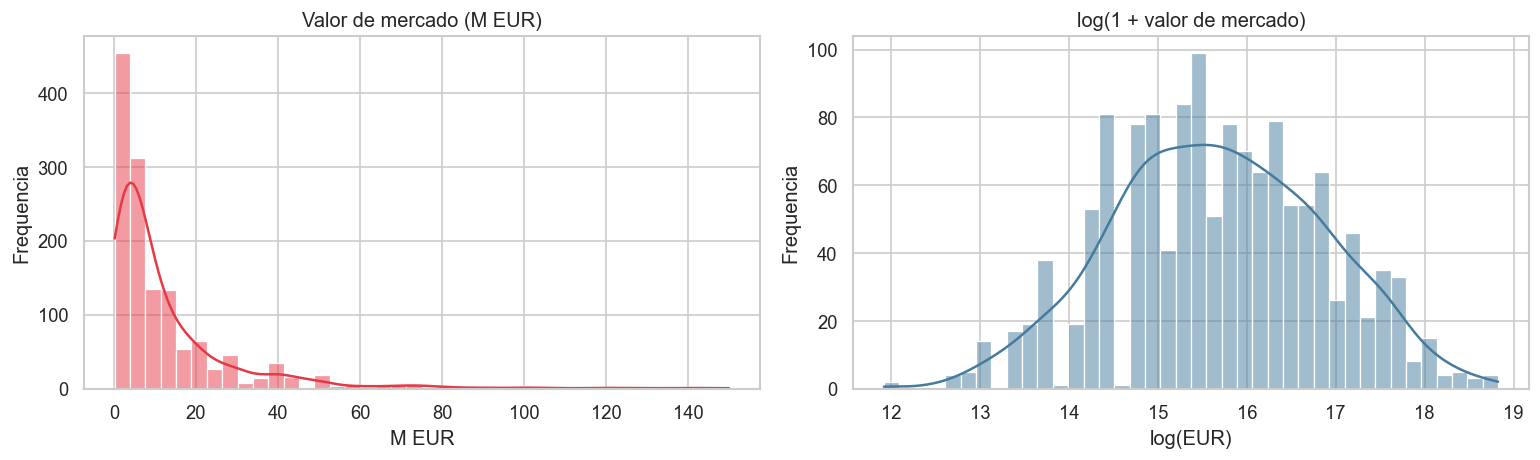

Assimetria original: 3.35 | em log: -0.01


In [4]:
# Alvo transformado: log(1 + valor). Suaviza a cauda longa da distribuicao.
df["log_mv"] = np.log1p(df["market_value"])

# Comparacao visual: distribuicao original (assimetrica) versus em escala log (mais simetrica).
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df["market_value"] / 1e6, bins=40, kde=True, ax=ax[0], color="#e63946")
ax[0].set(title="Valor de mercado (M EUR)", xlabel="M EUR", ylabel="Frequencia")
sns.histplot(df["log_mv"], bins=40, kde=True, ax=ax[1], color="#457b9d")
ax[1].set(title="log(1 + valor de mercado)", xlabel="log(EUR)", ylabel="Frequencia")
plt.tight_layout(); plt.show()

# skew perto de zero indica distribuicao aproximadamente simetrica.
print("Assimetria original:", round(df["market_value"].skew(), 2),
      "| em log:", round(df["log_mv"].skew(), 2))

## 4. Matriz de variaveis e divisao por jogador

Um cuidado central aqui e evitar vazamento de informacao, o chamado leakage. O mesmo jogador aparece em varias temporadas. Se usassemos uma divisao aleatoria comum, registros do mesmo atleta poderiam cair ao mesmo tempo no treino e no teste. O modelo entao decoraria aquele jogador especifico e o desempenho medido no teste ficaria artificialmente alto, sem refletir a capacidade real de generalizar para jogadores novos.

Para impedir isso usamos o `GroupShuffleSplit` agrupando por `player_name`. Assim garantimos que nenhum jogador esteja simultaneamente nos dois conjuntos. As variaveis categoricas `season`, `team` e `position` entram via One-Hot Encoding, que cria uma coluna binaria para cada categoria. As colunas de identificacao, como nome e identificadores, sao descartadas por nao terem valor preditivo.

In [5]:
# Variaveis numericas: estatisticas brutas, derivadas e idade.
num_features = [
    "age", "age_sq",
    "rating", "goals", "assists", "expectedGoals", "expectedAssists",
    "minutesPlayed", "matchesStarted", "appearances",
    "yellowCards", "redCards", "shotsOnTarget",
    "accuratePassesPercentage", "keyPasses", "successfulDribblesPercentage",
    "tackles", "interceptions", "bigChancesCreated", "bigChancesMissed",
    "goals_p90", "assists_p90", "shotsOnTarget_p90", "keyPasses_p90",
    "tackles_p90", "interceptions_p90", "bigChancesCreated_p90",
    "goals_assists", "ga_p90", "conv_rate", "fin_vs_xg", "create_vs_xa", "start_ratio",
]
# Variaveis categoricas que viram colunas binarias no One-Hot.
cat_features = ["season", "team", "position"]

X = df[num_features + cat_features].copy()
y = df["log_mv"].values          # alvo em escala log
groups = df["player_name"].values  # chave de agrupamento para evitar leakage

# Separa 20 por cento para teste, mantendo cada jogador inteiro em um so lado.
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
tr_idx, te_idx = next(gss.split(X, y, groups))
X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
y_tr, y_te = y[tr_idx], y[te_idx]
mv_te = df["market_value"].values[te_idx]  # valores reais em euros, para avaliar o erro

print(f"Treino: {len(X_tr)} registros | Teste: {len(X_te)} registros")
# Verificacao de seguranca: a interseccao de jogadores entre treino e teste deve ser vazia.
print("Jogadores presentes nos dois conjuntos (esperado 0):",
      len(set(groups[tr_idx]) & set(groups[te_idx])))

# Pre-processamento: padroniza os numeros (media 0, desvio 1) e aplica One-Hot nas categorias.
# sparse_output=False deixa a matriz densa, necessario para o SHAP mais adiante.
preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features),
])

Treino: 1071 registros | Teste: 280 registros
Jogadores presentes nos dois conjuntos (esperado 0): 0


## 5. Treino e comparacao de modelos

Comparamos cinco abordagens, da mais simples a mais sofisticada:

Baseline, que preve sempre a mediana. Serve de piso: qualquer modelo util precisa superar essa referencia.

Regressao Linear, uma soma ponderada das variaveis. E o modelo mais interpretavel e costuma ir bem quando a relacao, aqui em escala log, e proxima de linear.

Random Forest, uma media de muitas arvores de decisao treinadas em amostras aleatorias dos dados.

HistGradientBoosting, que constroi arvores em sequencia, cada uma corrigindo o erro da anterior.

XGBoost, uma implementacao de boosting muito usada como referencia na industria.

Reportamos as metricas em euros, revertendo a escala log: MAE (erro absoluto medio), RMSE (raiz do erro quadratico medio, que penaliza mais os erros grandes) e MAPE (erro percentual absoluto medio, util para comparar acertos entre jogadores baratos e caros). Tambem mostramos o R2 na escala log, que indica a fracao da variancia explicada pelo modelo.

In [6]:
# Dicionario de modelos. Cada um sera encaixado no mesmo pipeline de pre-processamento.
models = {
    "Baseline (mediana)": DummyRegressor(strategy="median"),
    "Regressao Linear": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=400, max_depth=None, min_samples_leaf=2,
        random_state=RANDOM_STATE, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=500, learning_rate=0.05, max_depth=None,
        random_state=RANDOM_STATE),
    "XGBoost": XGBRegressor(
        n_estimators=600, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, n_jobs=-1),
}

rows = []
fitted = {}   # guarda os pipelines treinados para reutilizar depois
for name, est in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", est)])
    pipe.fit(X_tr, y_tr)          # treina no conjunto de treino
    fitted[name] = pipe
    pred_log = pipe.predict(X_te)  # previsao ainda em escala log
    pred_eur = np.expm1(pred_log)  # de volta para euros
    rows.append({
        "Modelo": name,
        "MAE (M EUR)": mean_absolute_error(mv_te, pred_eur) / 1e6,
        "RMSE (M EUR)": np.sqrt(mean_squared_error(mv_te, pred_eur)) / 1e6,
        "MAPE (%)": mean_absolute_percentage_error(mv_te, pred_eur) * 100,
        "R2 (log)": r2_score(y_te, pred_log),
        "R2 (EUR)": r2_score(mv_te, pred_eur),
    })

# Ordena do melhor para o pior pela variancia explicada em log.
results = pd.DataFrame(rows).set_index("Modelo").round(3)
results.sort_values("R2 (log)", ascending=False)

,MAE (M EUR),RMSE (M EUR),MAPE (%),R2 (log),R2 (EUR)
Modelo,,,,,
XGBoost,4.805,9.607,33.896,0.876,0.761
Regressao Linear,4.706,9.044,34.757,0.872,0.788
HistGradientBoosting,5.177,10.441,40.184,0.839,0.717
Random Forest,6.957,12.809,52.816,0.746,0.575
Baseline (mediana),12.201,21.925,131.930,-0.063,-0.246


### Validacao cruzada agrupada por jogador

Um unico corte entre treino e teste pode ser otimista ou pessimista por sorte. Para confirmar que os numeros sao estaveis, repetimos a avaliacao com validacao cruzada em cinco particoes, sempre agrupando por jogador com o `GroupKFold`. Reportamos o R2 medio e o desvio padrao entre as particoes. Um desvio pequeno indica que o desempenho nao depende de um corte especifico dos dados.

In [7]:
# GroupKFold garante que, em cada uma das 5 rodadas, nenhum jogador aparece
# ao mesmo tempo no treino e na validacao.
gkf = GroupKFold(n_splits=5)
cv_rows = []
for name, est in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", est)])
    scores = cross_val_score(pipe, X, y, groups=groups, cv=gkf,
                             scoring="r2", n_jobs=-1)
    cv_rows.append({"Modelo": name, "R2 medio": scores.mean(), "desvio": scores.std()})
pd.DataFrame(cv_rows).set_index("Modelo").round(3).sort_values("R2 medio", ascending=False)

,R2 medio,desvio
Modelo,,
Regressao Linear,0.838,0.042
XGBoost,0.809,0.038
HistGradientBoosting,0.774,0.038
Random Forest,0.676,0.035
Baseline (mediana),-0.010,0.010


## 6. Melhor modelo: previsto contra real e residuos

Selecionamos automaticamente o modelo com maior R2 em log para o diagnostico. O grafico da esquerda compara o valor previsto com o real: quanto mais perto da diagonal tracejada, melhor a previsao. O grafico da direita mostra os residuos, ou seja, a diferenca entre previsto e real. Um bom modelo deixa os residuos espalhados em torno de zero, sem tendencia clara.

Melhor modelo: XGBoost


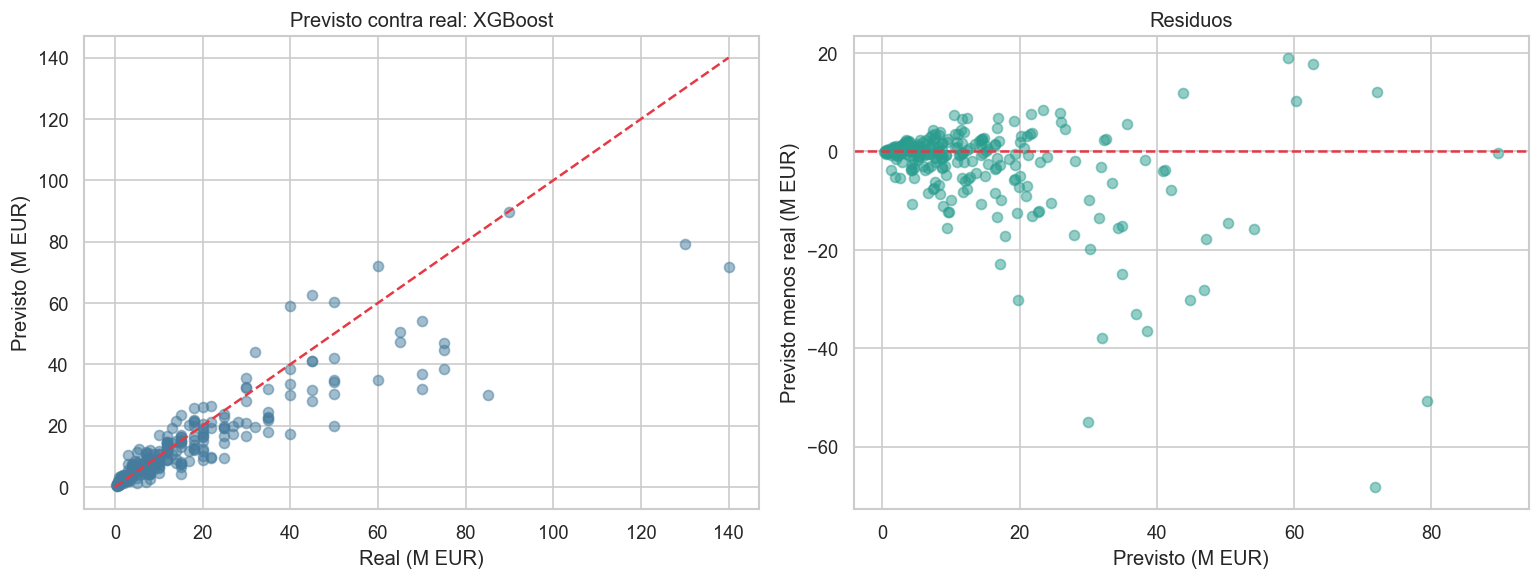

In [8]:
# Escolhe o modelo campeao pela metrica principal e recupera suas previsoes.
best_name = results.sort_values("R2 (log)", ascending=False).index[0]
best = fitted[best_name]
pred_log = best.predict(X_te)
pred_eur = np.expm1(pred_log)
print("Melhor modelo:", best_name)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
# Dispersao previsto x real, com a reta y = x como referencia de acerto perfeito.
ax[0].scatter(mv_te / 1e6, pred_eur / 1e6, alpha=0.5, color="#457b9d")
lim = max(mv_te.max(), pred_eur.max()) / 1e6
ax[0].plot([0, lim], [0, lim], "--", color="#e63946")
ax[0].set(title=f"Previsto contra real: {best_name}",
          xlabel="Real (M EUR)", ylabel="Previsto (M EUR)")

# Residuos em funcao do valor previsto. A linha em zero marca o acerto exato.
resid = (pred_eur - mv_te) / 1e6
ax[1].scatter(pred_eur / 1e6, resid, alpha=0.5, color="#2a9d8f")
ax[1].axhline(0, ls="--", color="#e63946")
ax[1].set(title="Residuos", xlabel="Previsto (M EUR)", ylabel="Previsto menos real (M EUR)")
plt.tight_layout(); plt.show()

## 7. Erro por faixa de valor

A metrica global esconde uma diferenca importante. Errar 5 milhoes na avaliacao de um jogador que vale 100 milhoes e proporcionalmente pequeno, mas o mesmo erro em um jogador de 3 milhoes e enorme. Por isso quebramos o conjunto de teste em faixas de valor e olhamos duas coisas em cada faixa: o MAE, que e o erro medio em euros, e o MAPE, que e o erro em porcentagem do valor real. Isso mostra onde o modelo e realmente confiavel e onde ele apenas acerta a ordem de grandeza.

         n  MAE_M  MAPE_med
faixa                      
0-2M    48    0.7      39.5
2-5M    52    1.5      24.8
5-10M   55    2.0      17.1
10-30M  87    4.5      20.8
>30M    38   19.3      36.2


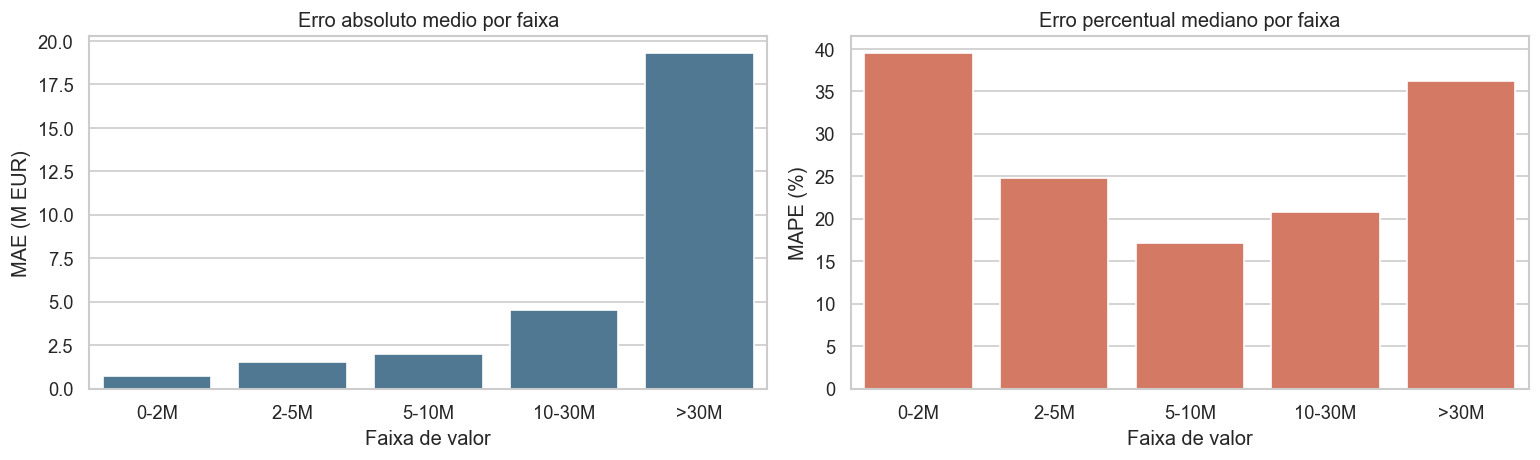

In [9]:
# Agrupa os jogadores do teste em faixas de valor de mercado.
faixas = pd.cut(mv_te,
                bins=[0, 2e6, 5e6, 10e6, 30e6, 200e6],
                labels=["0-2M", "2-5M", "5-10M", "10-30M", ">30M"])

err = pd.DataFrame({"real": mv_te, "prev": pred_eur, "faixa": faixas})
err["erro_abs"] = (err["prev"] - err["real"]).abs()             # erro em euros
err["erro_pct"] = err["erro_abs"] / err["real"] * 100           # erro em porcentagem

# Resumo por faixa: quantidade, erro medio em milhoes e erro percentual mediano.
resumo = err.groupby("faixa", observed=True).agg(
    n=("real", "size"),
    MAE_M=("erro_abs", lambda x: x.mean() / 1e6),
    MAPE_med=("erro_pct", "median"),
).round(1)
print(resumo)

# Visualizacao lado a lado: erro absoluto cresce com o valor, erro percentual costuma cair.
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(x=resumo.index, y=resumo["MAE_M"], ax=ax[0], color="#457b9d")
ax[0].set(title="Erro absoluto medio por faixa", xlabel="Faixa de valor", ylabel="MAE (M EUR)")
sns.barplot(x=resumo.index, y=resumo["MAPE_med"], ax=ax[1], color="#e76f51")
ax[1].set(title="Erro percentual mediano por faixa", xlabel="Faixa de valor", ylabel="MAPE (%)")
plt.tight_layout(); plt.show()

## 8. Importancia das variaveis

A importancia por permutacao mede quanto o desempenho do modelo piora quando embaralhamos aleatoriamente uma variavel de cada vez. Se embaralhar uma coluna derruba muito o R2, aquela variavel era importante. A tecnica e robusta e funciona para qualquer tipo de modelo, o que permite comparar de forma justa. Ela responde a pergunta central do projeto: quais informacoes mais determinam o valor de mercado.

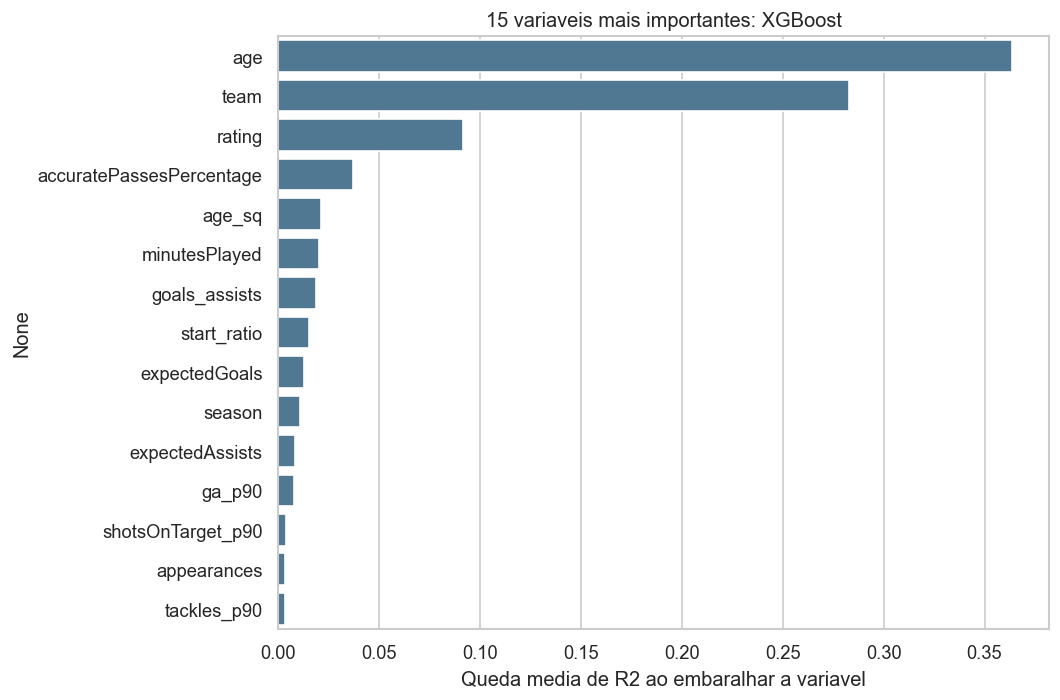

age                         0.3637
team                        0.2829
rating                      0.0915
accuratePassesPercentage    0.0371
age_sq                      0.0210
minutesPlayed               0.0201
goals_assists               0.0188
start_ratio                 0.0151
expectedGoals               0.0126
season                      0.0108
expectedAssists             0.0080
ga_p90                      0.0079
shotsOnTarget_p90           0.0038
appearances                 0.0035
tackles_p90                 0.0033
dtype: float64

In [10]:
# n_repeats controla quantas vezes cada coluna e embaralhada; mais repeticoes, estimativa mais estavel.
perm = permutation_importance(best, X_te, y_te, n_repeats=15,
                              random_state=RANDOM_STATE, n_jobs=-1)
imp = (pd.Series(perm.importances_mean, index=X_te.columns)
       .sort_values(ascending=False).head(15))

plt.figure(figsize=(9, 6))
sns.barplot(x=imp.values, y=imp.index, color="#457b9d")
plt.title(f"15 variaveis mais importantes: {best_name}")
plt.xlabel("Queda media de R2 ao embaralhar a variavel")
plt.tight_layout(); plt.show()
imp.round(4)

## 9. Explicabilidade do modelo

A importancia por permutacao diz quais variaveis pesam, mas nao diz a direcao nem o formato do efeito. Aqui aprofundamos isso de tres formas complementares.

Primeiro, os valores SHAP. O SHAP atribui a cada variavel, em cada previsao individual, uma contribuicao em pontos: quanto ela empurrou a previsao para cima ou para baixo em relacao a media. O grafico de resumo mostra todos os jogadores de uma vez. Cada ponto e um jogador, a posicao horizontal e a contribuicao para o valor previsto e a cor indica se o valor daquela variavel era alto (vermelho) ou baixo (azul). Assim vemos, por exemplo, se idade alta empurra o valor para baixo.

Segundo, a dependencia parcial da idade. Ela mostra o efeito medio da idade sobre a previsao, isolando as demais variaveis, e deixa visivel a curva de pico de carreira.

Terceiro, os coeficientes da Regressao Linear. Como esse modelo e competitivo, seus pesos sao diretamente interpretaveis: em escala log e com as variaveis padronizadas, um coeficiente positivo significa que aumentar aquela variavel aumenta o valor previsto.

C:\Users\Caio U. Evangelista\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


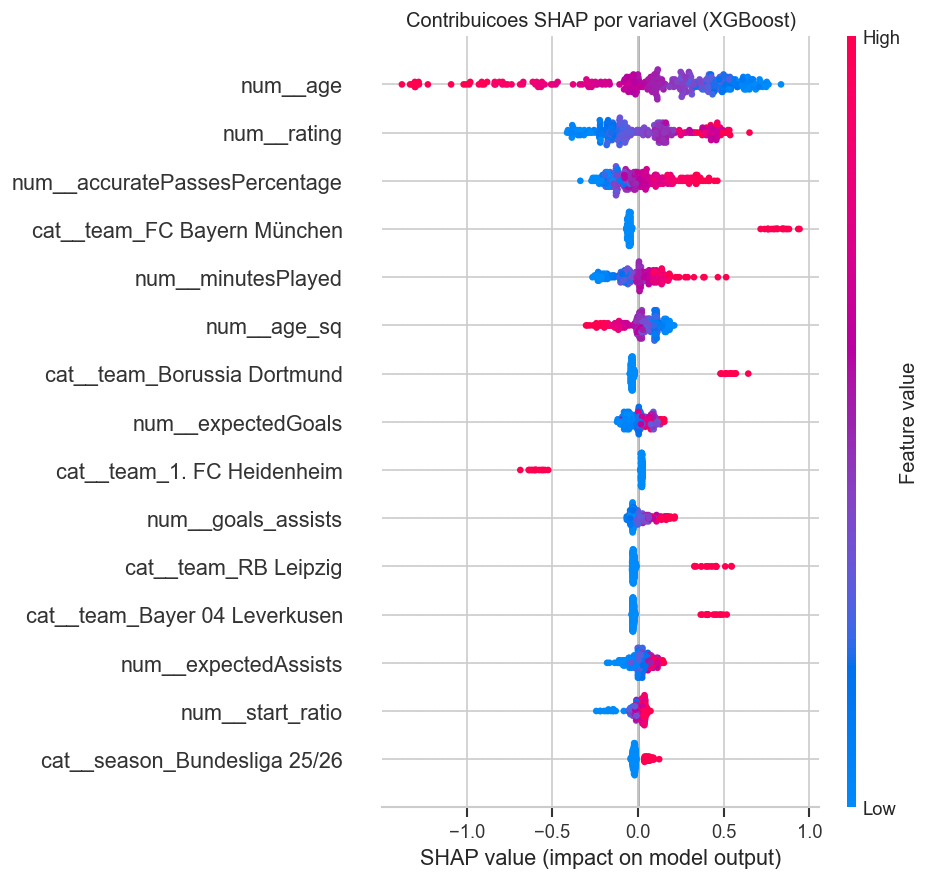

In [11]:
import shap

# O SHAP com TreeExplainer exige um modelo de arvores, entao usamos o XGBoost treinado,
# independentemente de qual foi o melhor modelo, pois ele e proprio para essa analise.
xgb_pipe = fitted["XGBoost"]
prep = xgb_pipe.named_steps["prep"]
feat_names = prep.get_feature_names_out()          # nomes apos o One-Hot
X_te_trans = prep.transform(X_te)                   # dados ja pre-processados (densos)

# TreeExplainer calcula as contribuicoes SHAP de forma exata e rapida em arvores.
explainer = shap.TreeExplainer(xgb_pipe.named_steps["model"])
shap_values = explainer.shap_values(X_te_trans)

# Grafico de resumo (beeswarm): visao global de como cada variavel afeta as previsoes.
shap.summary_plot(shap_values, X_te_trans, feature_names=feat_names,
                  max_display=15, show=False)
plt.title("Contribuicoes SHAP por variavel (XGBoost)")
plt.tight_layout(); plt.show()

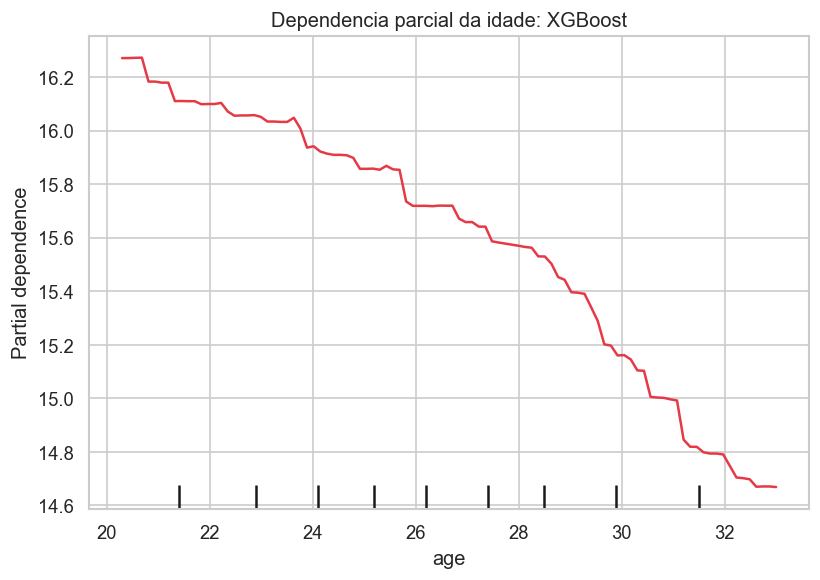

In [12]:
# Dependencia parcial: efeito medio isolado da idade sobre o valor previsto (em log).
# Torna visivel a curva de pico de carreira captada pelo termo age e age_sq.
fig, ax = plt.subplots(figsize=(7, 5))
PartialDependenceDisplay.from_estimator(
    best, X_tr, features=["age"], ax=ax, line_kw={"color": "#e63946"})
ax.set(title=f"Dependencia parcial da idade: {best_name}",
       xlabel="Idade (anos)", ylabel="Efeito no valor previsto (log)")
plt.tight_layout(); plt.show()

C:\Users\Caio U. Evangelista\AppData\Local\Temp\ipykernel_15512\4084631913.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index, palette=cores)


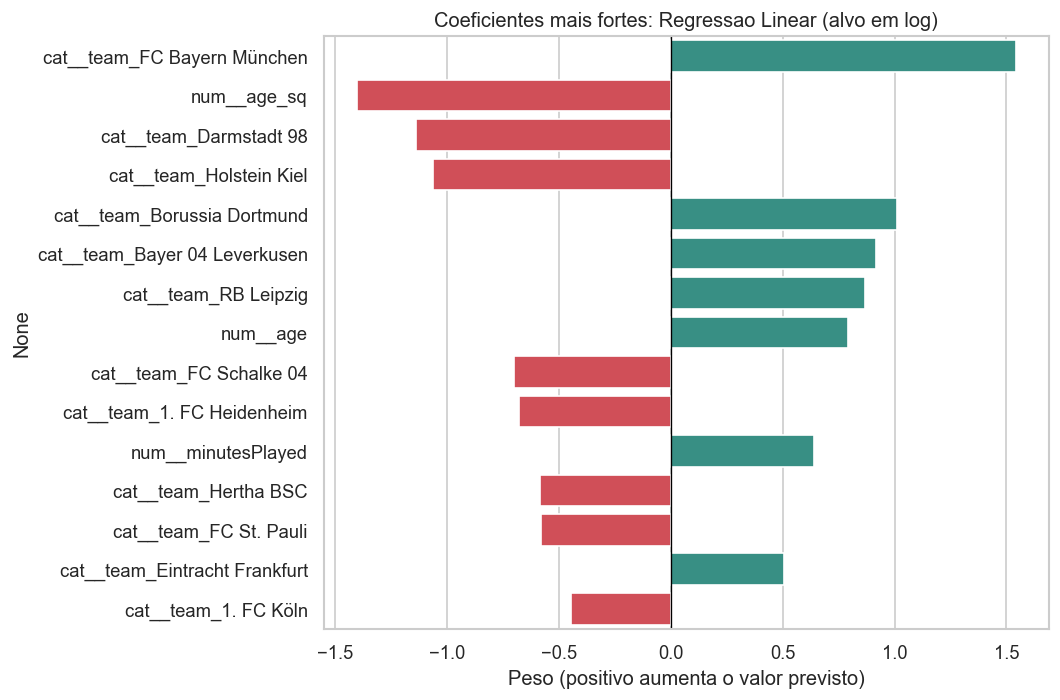

cat__team_FC Bayern München      1.542
num__age_sq                     -1.405
cat__team_Darmstadt 98          -1.138
cat__team_Holstein Kiel         -1.065
cat__team_Borussia Dortmund      1.013
cat__team_Bayer 04 Leverkusen    0.917
cat__team_RB Leipzig             0.866
num__age                         0.793
cat__team_FC Schalke 04         -0.704
cat__team_1. FC Heidenheim      -0.679
num__minutesPlayed               0.640
cat__team_Hertha BSC            -0.585
cat__team_FC St. Pauli          -0.582
cat__team_Eintracht Frankfurt    0.506
cat__team_1. FC Köln            -0.447
dtype: float64

In [13]:
# Coeficientes da Regressao Linear: leitura direta de quais variaveis puxam o valor para cima ou para baixo.
lin = fitted["Regressao Linear"]
lin_names = lin.named_steps["prep"].get_feature_names_out()
coefs = pd.Series(lin.named_steps["model"].coef_, index=lin_names)

# Seleciona os 15 maiores em modulo, ou seja, os efeitos mais fortes em qualquer direcao.
top = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(15)
plt.figure(figsize=(9, 6))
cores = ["#2a9d8f" if v > 0 else "#e63946" for v in top.values]  # verde sobe, vermelho desce
sns.barplot(x=top.values, y=top.index, palette=cores)
plt.axvline(0, color="black", lw=0.8)
plt.title("Coeficientes mais fortes: Regressao Linear (alvo em log)")
plt.xlabel("Peso (positivo aumenta o valor previsto)")
plt.tight_layout(); plt.show()
top.round(3)

## 10. Aplicacao pratica: jogadores subvalorizados e supervalorizados

Este e o produto que o projeto busca entregar. Usando o residuo do melhor modelo no conjunto de teste, identificamos atletas cujo valor de mercado destoa do que as estatisticas sustentam.

Residuo positivo, previsto acima do real, significa que o desempenho justifica um valor maior que o de mercado, o que aponta uma possivel oportunidade de contratacao, um jogador subvalorizado.

Residuo negativo, previsto abaixo do real, indica que o preco esta acima do que o desempenho sustenta, um sinal de risco, um jogador supervalorizado.

Vale a ressalva vista na secao de erro por faixa: para jogadores muito baratos o erro percentual e maior, entao a lista funciona melhor como triagem para investigacao do que como avaliacao de preco exato.

In [14]:
# Monta a tabela de diagnostico com valor real, previsto e residuo (tudo em milhoes).
diag = df.iloc[te_idx][["player_name", "team", "season", "position", "age", "market_value"]].copy()
diag["previsto"] = pred_eur
diag["residuo"] = diag["previsto"] - diag["market_value"]
for c in ["market_value", "previsto", "residuo"]:
    diag[c] = (diag[c] / 1e6).round(1)
diag = diag.rename(columns={"market_value": "real_M", "previsto": "prev_M", "residuo": "resid_M"})

# Maiores residuos positivos: desempenho acima do preco.
print("=== TOP 10 SUBVALORIZADOS (desempenho acima do preco) ===")
print(diag.sort_values("resid_M", ascending=False).head(10).to_string(index=False))
# Maiores residuos negativos: preco acima do desempenho.
print("\n=== TOP 10 SUPERVALORIZADOS (preco acima do desempenho) ===")
print(diag.sort_values("resid_M").head(10).to_string(index=False))

=== TOP 10 SUBVALORIZADOS (desempenho acima do preco) ===
   player_name                team           season position  age  real_M    prev_M  resid_M
   Tom Bischof   FC Bayern München Bundesliga 25/26        M 20.1    40.0 59.099998     19.1
  Ibrahim Maza Bayer 04 Leverkusen Bundesliga 25/26        F 19.7    45.0 62.799999     17.8
  Lennart Karl   FC Bayern München Bundesliga 25/26        M 17.4    60.0 72.099998     12.1
    Leroy Sané   FC Bayern München Bundesliga 24/25        M 28.6    32.0 43.900002     11.9
 Jamie Gittens   Borussia Dortmund Bundesliga 24/25        M 20.0    50.0 60.299999     10.3
  Farès Chaïbi Eintracht Frankfurt Bundesliga 25/26        M 22.7    15.0 23.400000      8.4
  Farès Chaïbi Eintracht Frankfurt Bundesliga 23/24        M 20.7    18.0 25.900000      7.9
 Jamie Gittens   Borussia Dortmund Bundesliga 22/23        M 18.0    14.0 21.700001      7.7
   Anrie Chase       VfB Stuttgart Bundesliga 24/25        D 20.4     3.0 10.400000      7.4
Nnamdi Colli

## 11. Sintese

Os modelos de boosting e a regressao linear estimam o valor de mercado a partir das estatisticas de desempenho, da idade e da posicao, validados por validacao cruzada agrupada por jogador, sem vazamento de informacao. A regressao linear alcanca desempenho proximo do XGBoost, o que indica que o ganho principal veio das variaveis escolhidas, e nao da complexidade do algoritmo.

A idade aparece como a variavel mais determinante, seguida do clube e do rating, um resultado coerente com a teoria de valoracao de ativos discutida no relatorio, em que o ciclo de vida do atleta pesa muito na precificacao. A analise por faixa de valor mostra que o modelo e mais preciso, em termos percentuais, para jogadores de valor medio e alto, e menos preciso para os mais baratos.

A analise de residuos entrega diretamente o produto pretendido pelo projeto: uma lista de jogadores subvalorizados, candidatos a contratacao, e supervalorizados, sinal de risco financeiro.

Como continuidade natural, o modelo pode incorporar o historico de lesoes e o tempo restante de contrato do Transfermarkt, alem de comparar o valor de mercado estimado com o valor efetivamente pago em transferencias, o chamado agio, ja explorado nas consultas do relatorio.